In [1]:
# Install small supporting package
%pip -q install holidays

import os
import json
import time
import random
import warnings
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import holidays
import joblib

from IPython.display import display
from scipy import stats

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings("ignore")

CONFIG = {
    "start_date": "2015-01-01",
    "end_date": "2020-10-31 23:59:59",
    "test_weeks": 104,
    "seasonal_period": 52,
    "week_frequency": "W-MON",
    "seed": 42
}

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
tf.random.set_seed(CONFIG["seed"])

for folder in ["figures", "results", "models"]:
    os.makedirs(folder, exist_ok=True)


def smape(actual, forecast):
    """Symmetric percentage error."""
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)

    denominator = np.abs(actual) + np.abs(forecast)
    valid = denominator != 0

    return np.mean(
        200 * np.abs(actual[valid] - forecast[valid]) /
        denominator[valid]
    )


def evaluate_forecast(name, actual, forecast, training):
    """Common evaluation used for every model."""
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    training = np.asarray(training, dtype=float)

    errors = forecast - actual
    absolute_errors = np.abs(errors)
    m = CONFIG["seasonal_period"]

    seasonal_absolute_scale = np.mean(
        np.abs(training[m:] - training[:-m])
    )

    seasonal_squared_scale = np.mean(
        (training[m:] - training[:-m]) ** 2
    )

    return {
        "Model": name,
        "MAE": absolute_errors.mean(),
        "RMSE": np.sqrt(np.mean(errors ** 2)),
        "sMAPE (%)": smape(actual, forecast),
        "MASE": absolute_errors.mean() / seasonal_absolute_scale,
        "RMSSE": np.sqrt(
            np.mean(errors ** 2) / seasonal_squared_scale
        ),
        "Median AE": np.median(absolute_errors),
        "90th percentile AE": np.quantile(absolute_errors, 0.90),
        "Bias": errors.mean(),
        "Error stability": absolute_errors.std()
    }


def check_forecast_dates(actual, forecasts):
    """Confirm identical dates for every model."""
    for name, forecast in forecasts.items():
        assert forecast.index.equals(actual.index), (
            f"{name} does not use the common test dates."
        )
        assert forecast.notna().all(), (
            f"{name} contains missing predictions."
        )

    print("All models predict exactly the same dates.")


def save_plot(filename):
    """Save each figure consistently."""
    plt.tight_layout()
    plt.savefig(
        f"figures/{filename}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()


print("Environment prepared successfully")

Environment prepared successfully


In [2]:
# German hourly electricity-demand source
DATA_URL = (
    "https://data.open-power-system-data.org/time_series/"
    "2020-10-06/time_series_60min_singleindex.csv"
)

# Find the correct German load column
available_columns = pd.read_csv(
    DATA_URL,
    nrows=0
).columns.tolist()

preferred_column = "DE_load_actual_entsoe_transparency"

if preferred_column in available_columns:
    demand_column = preferred_column
else:
    matching_columns = [
        column for column in available_columns
        if column.startswith("DE_")
        and "load" in column.lower()
        and "actual" in column.lower()
    ]

    if not matching_columns:
        raise ValueError("German load column was not found.")

    demand_column = matching_columns[0]

# Load only the required columns
electricity = pd.read_csv(
    DATA_URL,
    usecols=["utc_timestamp", demand_column]
)

electricity["utc_timestamp"] = pd.to_datetime(
    electricity["utc_timestamp"],
    utc=True
).dt.tz_convert(None)

electricity[demand_column] = pd.to_numeric(
    electricity[demand_column],
    errors="coerce"
)

electricity = (
    electricity
    .set_index("utc_timestamp")
    .sort_index()
    .rename(columns={demand_column: "demand"})
)

# Keep January 2015 through the available October 2020 data
electricity = electricity.loc[
    CONFIG["start_date"]:CONFIG["end_date"]
].copy()

# Combine duplicate timestamps if any exist
electricity = electricity.groupby(level=0).mean()

# Rebuild the continuous hourly timeline
hourly_index = pd.date_range(
    electricity.index.min(),
    electricity.index.max(),
    freq="h"
)

hourly_original = electricity["demand"].reindex(
    hourly_index
)

missing_before = hourly_original.isna().sum()

# Fill only missing internal observations
hourly = (
    hourly_original
    .interpolate(method="time")
    .ffill()
    .bfill()
)

hourly.name = "demand"

# Create daily and weekly means
daily = hourly.resample("D").mean()

weekly_mean = hourly.resample(
    CONFIG["week_frequency"],
    label="left",
    closed="left"
).mean()

weekly_hours = pd.Series(
    1,
    index=hourly.index
).resample(
    CONFIG["week_frequency"],
    label="left",
    closed="left"
).sum()

# Use only complete 168-hour weeks
complete_week_mask = weekly_hours == 168

weekly = weekly_mean.loc[
    complete_week_mask
].dropna()

# One common chronological test period
test = weekly.iloc[-CONFIG["test_weeks"]:].copy()
train = weekly.iloc[:-CONFIG["test_weeks"]].copy()

data_summary = pd.DataFrame({
    "Item": [
        "Raw start",
        "Raw end",
        "Hourly observations",
        "Missing values filled",
        "Daily observations",
        "Complete weekly observations",
        "Training weeks",
        "Testing weeks"
    ],
    "Value": [
        hourly.index.min(),
        hourly.index.max(),
        len(hourly),
        missing_before,
        len(daily),
        len(weekly),
        len(train),
        len(test)
    ]
})

display(data_summary)

print("\nTraining period:",
      train.index.min(), "to", train.index.max())

print("Testing period:",
      test.index.min(), "to", test.index.max())

,Item,Value
0,Raw start,2015-01-01 00:00:00
1,Raw end,2020-09-30 23:00:00
2,Hourly observations,50400
3,Missing values filled,0
4,Daily observations,2100
5,Complete weekly observations,299
6,Training weeks,195
7,Testing weeks,104



Training period: 2015-01-05 00:00:00 to 2018-09-24 00:00:00
Testing period: 2018-10-01 00:00:00 to 2020-09-21 00:00:00


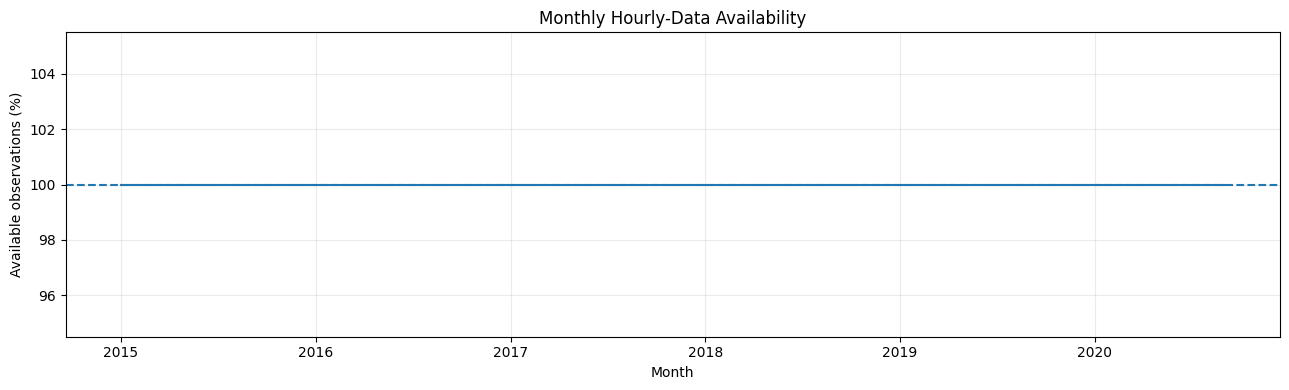

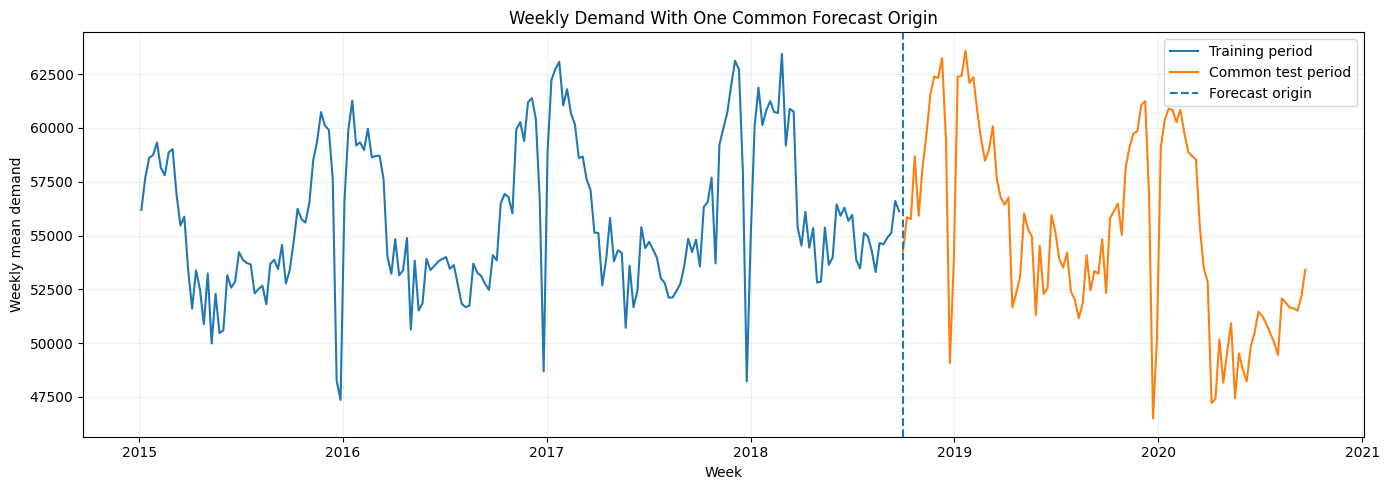

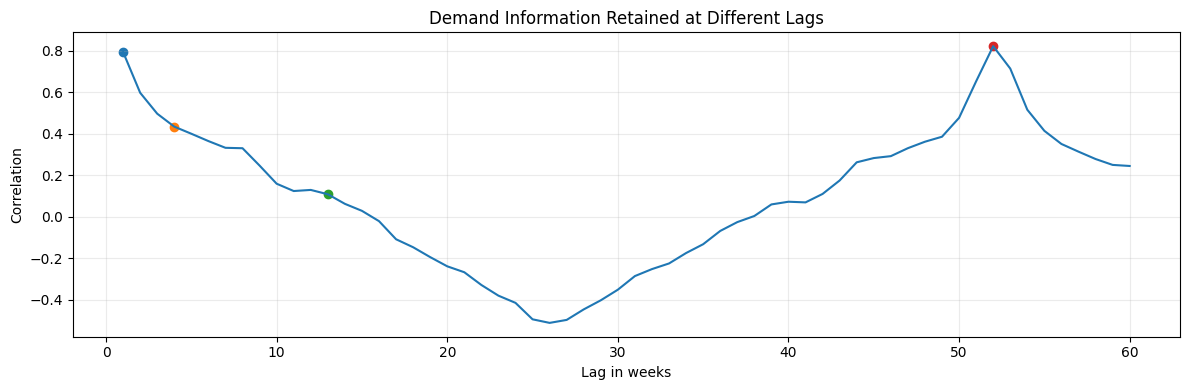

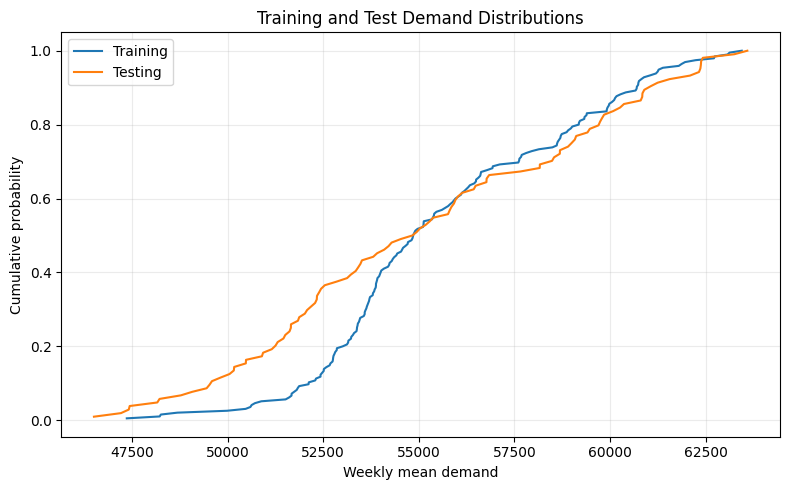

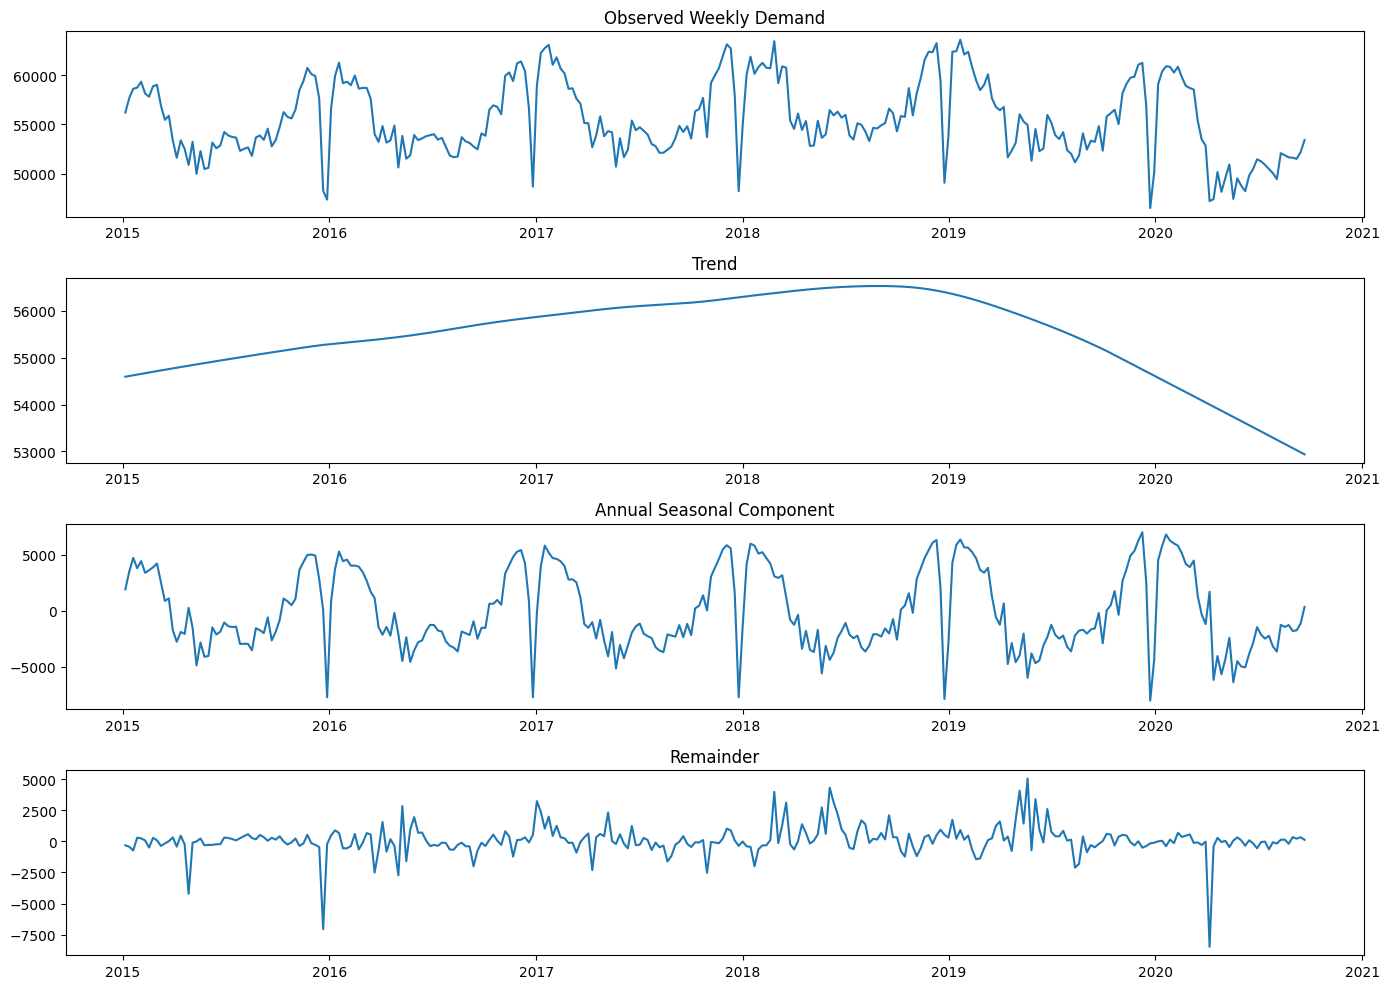

,Series,ADF statistic,ADF p-value,KPSS statistic,KPSS p-value
0,Original,-3.9005,0.0020,0.1632,0.10
1,First difference,-7.0351,0.0000,0.0313,0.10
2,Seasonal difference,-1.8042,0.3784,1.4238,0.01
3,First and seasonal difference,-7.6900,0.0000,0.0346,0.10


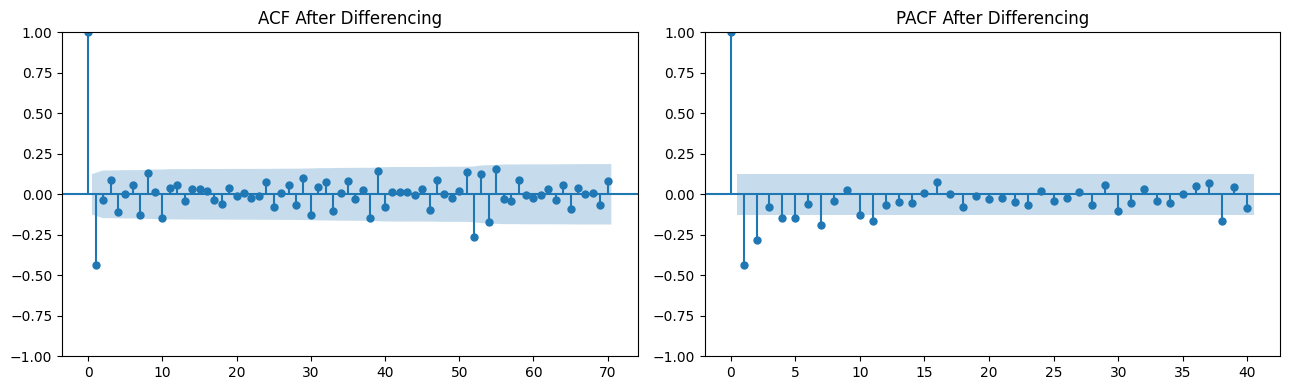

In [3]:
# ------------------------------------------------------------
# Plot 1: Monthly data availability
# ------------------------------------------------------------

monthly_availability = (
    hourly_original.notna()
    .astype(int)
    .resample("MS")
    .mean() * 100
)

plt.figure(figsize=(13, 4))
plt.plot(
    monthly_availability.index,
    monthly_availability
)

plt.axhline(100, linestyle="--")
plt.title("Monthly Hourly-Data Availability")
plt.xlabel("Month")
plt.ylabel("Available observations (%)")
plt.grid(alpha=0.25)
save_plot("monthly_data_availability")

# ------------------------------------------------------------
# Plot 2: Common training and test split
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))
plt.plot(train.index, train, label="Training period")
plt.plot(test.index, test, label="Common test period")

plt.axvline(
    test.index.min(),
    linestyle="--",
    label="Forecast origin"
)

plt.title("Weekly Demand With One Common Forecast Origin")
plt.xlabel("Week")
plt.ylabel("Weekly mean demand")
plt.legend()
plt.grid(alpha=0.20)
save_plot("common_train_test_split")

# ------------------------------------------------------------
# Plot 3: Lag-information decay
# ------------------------------------------------------------

lag_correlations = pd.Series({
    lag: weekly.corr(weekly.shift(lag))
    for lag in range(1, 61)
})

plt.figure(figsize=(12, 4))
plt.plot(
    lag_correlations.index,
    lag_correlations.values
)

for important_lag in [1, 4, 13, 52]:
    plt.scatter(
        important_lag,
        lag_correlations.loc[important_lag]
    )

plt.title("Demand Information Retained at Different Lags")
plt.xlabel("Lag in weeks")
plt.ylabel("Correlation")
plt.grid(alpha=0.25)
save_plot("lag_information_decay")

# ------------------------------------------------------------
# Plot 4: Training-test distribution shift
# ------------------------------------------------------------

train_sorted = np.sort(train.to_numpy())
test_sorted = np.sort(test.to_numpy())

train_probability = np.arange(
    1, len(train_sorted) + 1
) / len(train_sorted)

test_probability = np.arange(
    1, len(test_sorted) + 1
) / len(test_sorted)

plt.figure(figsize=(8, 5))
plt.plot(
    train_sorted,
    train_probability,
    label="Training"
)

plt.plot(
    test_sorted,
    test_probability,
    label="Testing"
)

plt.title("Training and Test Demand Distributions")
plt.xlabel("Weekly mean demand")
plt.ylabel("Cumulative probability")
plt.legend()
plt.grid(alpha=0.25)
save_plot("train_test_distribution")

# ------------------------------------------------------------
# Seasonal decomposition
# ------------------------------------------------------------

stl_result = STL(
    weekly,
    period=CONFIG["seasonal_period"],
    robust=True
).fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

axes[0].plot(weekly)
axes[0].set_title("Observed Weekly Demand")

axes[1].plot(stl_result.trend)
axes[1].set_title("Trend")

axes[2].plot(stl_result.seasonal)
axes[2].set_title("Annual Seasonal Component")

axes[3].plot(stl_result.resid)
axes[3].set_title("Remainder")

plt.tight_layout()
plt.savefig(
    "figures/stl_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ------------------------------------------------------------
# Stationarity tests
# ------------------------------------------------------------

def stationarity_result(series, name):
    """Run ADF and KPSS consistently."""
    series = series.dropna()

    adf_output = adfuller(series, autolag="AIC")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_output = kpss(
            series,
            regression="c",
            nlags="auto"
        )

    return {
        "Series": name,
        "ADF statistic": adf_output[0],
        "ADF p-value": adf_output[1],
        "KPSS statistic": kpss_output[0],
        "KPSS p-value": kpss_output[1]
    }


first_difference = weekly.diff()
seasonal_difference = weekly.diff(52)
combined_difference = weekly.diff().diff(52)

stationarity_table = pd.DataFrame([
    stationarity_result(
        weekly,
        "Original"
    ),
    stationarity_result(
        first_difference,
        "First difference"
    ),
    stationarity_result(
        seasonal_difference,
        "Seasonal difference"
    ),
    stationarity_result(
        combined_difference,
        "First and seasonal difference"
    )
])

display(stationarity_table.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_acf(
    combined_difference.dropna(),
    lags=70,
    ax=axes[0]
)

plot_pacf(
    combined_difference.dropna(),
    lags=40,
    method="ywm",
    ax=axes[1]
)

axes[0].set_title("ACF After Differencing")
axes[1].set_title("PACF After Differencing")

plt.tight_layout()
plt.savefig(
    "figures/acf_pacf_differenced.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

,Model,MAE,RMSE,sMAPE (%),MASE,RMSSE,Median AE,90th percentile AE,Bias,Error stability
2,Seasonal Naive,2288.4892,2988.2483,4.2067,1.6938,1.6262,1703.6875,4894.1970,1747.8046,1921.5736
0,Mean,3789.8453,4402.0588,6.8738,2.8051,2.3956,3737.3382,6676.3686,561.1923,2239.4629
3,Drift,3850.7758,4466.4944,6.9823,2.8502,2.4307,3776.0060,6617.6209,966.3860,2262.9844
1,Naive,3858.1478,4475.7671,6.9954,2.8556,2.4358,3790.3512,6650.1137,984.5335,2268.7412


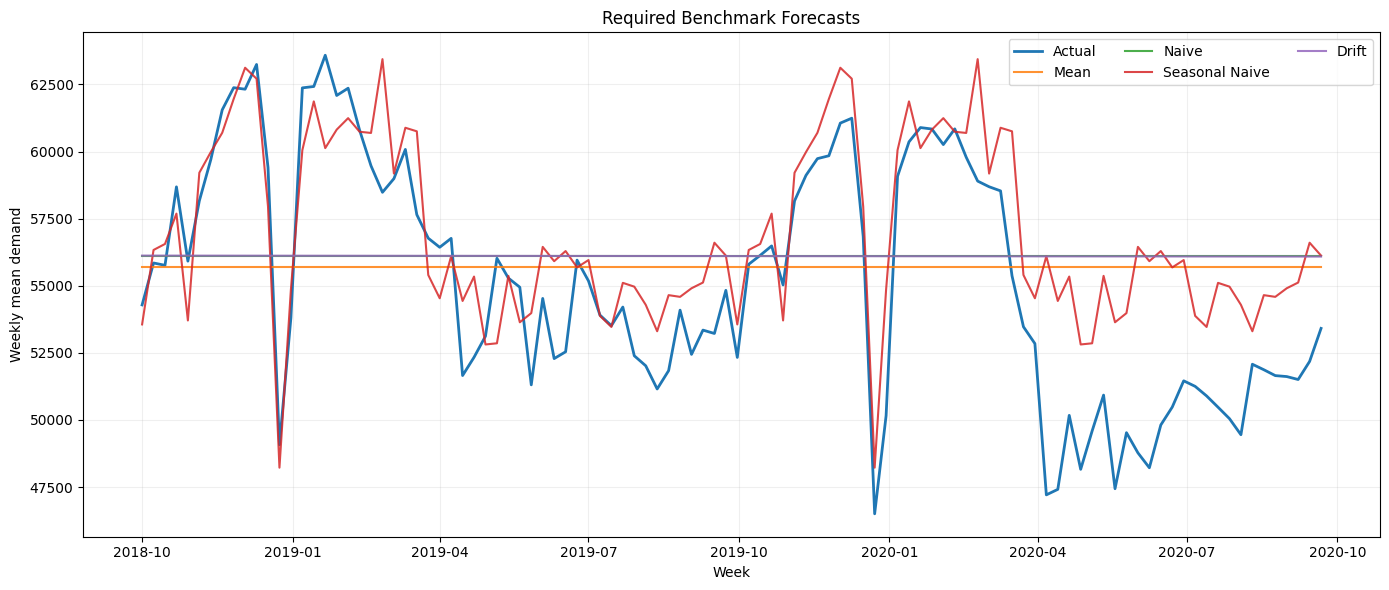

In [4]:
# Common benchmark function
def create_benchmarks(train_series, test_index):
    horizon = len(test_index)

    mean_forecast = pd.Series(
        train_series.mean(),
        index=test_index
    )

    naive_forecast = pd.Series(
        train_series.iloc[-1],
        index=test_index
    )

    seasonal_values = np.tile(
        train_series.iloc[-52:].to_numpy(),
        int(np.ceil(horizon / 52))
    )[:horizon]

    seasonal_forecast = pd.Series(
        seasonal_values,
        index=test_index
    )

    weekly_drift = (
        train_series.iloc[-1] -
        train_series.iloc[0]
    ) / (len(train_series) - 1)

    drift_forecast = pd.Series(
        train_series.iloc[-1] +
        weekly_drift *
        np.arange(1, horizon + 1),
        index=test_index
    )

    return {
        "Mean": mean_forecast,
        "Naive": naive_forecast,
        "Seasonal Naive": seasonal_forecast,
        "Drift": drift_forecast
    }


forecasts = create_benchmarks(
    train,
    test.index
)

intervals = {}

benchmark_results = pd.DataFrame([
    evaluate_forecast(
        name,
        test,
        forecast,
        train
    )
    for name, forecast in forecasts.items()
])

display(
    benchmark_results
    .sort_values("RMSE")
    .round(4)
)

plt.figure(figsize=(14, 6))
plt.plot(test.index, test, label="Actual", linewidth=2)

for name, forecast in forecasts.items():
    plt.plot(
        forecast.index,
        forecast,
        label=name,
        alpha=0.85
    )

plt.title("Required Benchmark Forecasts")
plt.xlabel("Week")
plt.ylabel("Weekly mean demand")
plt.legend(ncol=3)
plt.grid(alpha=0.20)
save_plot("benchmark_forecasts")

Testing 147 required SARIMA combinations...
Completed 25/147
Completed 50/147
Completed 75/147
Completed 100/147
Completed 125/147

Best SARIMA combinations


,order,AIC,converged,status
13,"(0, 1, 6)",1444.014,True,Successful
34,"(1, 1, 6)",1445.807,True,Successful
33,"(1, 1, 5)",1462.737,True,Successful
12,"(0, 1, 5)",1464.920,True,Successful
6,"(0, 0, 6)",1472.119,True,Successful
11,"(0, 1, 4)",1479.910,True,Successful
32,"(1, 1, 4)",1481.839,True,Successful
5,"(0, 0, 5)",1487.674,True,Successful
10,"(0, 1, 3)",1496.534,True,Successful
31,"(1, 1, 3)",1498.520,True,Successful


Successful: 147
Failed: 0

Selected order: (0, 1, 6)
Seasonal order: (0, 1, 1, 52)


,Model,MAE,RMSE,sMAPE (%),MASE,RMSSE,Median AE,90th percentile AE,Bias,Error stability
0,SARIMA,3109.6698,3836.6129,5.6407,2.3016,2.0879,2725.4857,6133.7022,2903.561,2247.1208


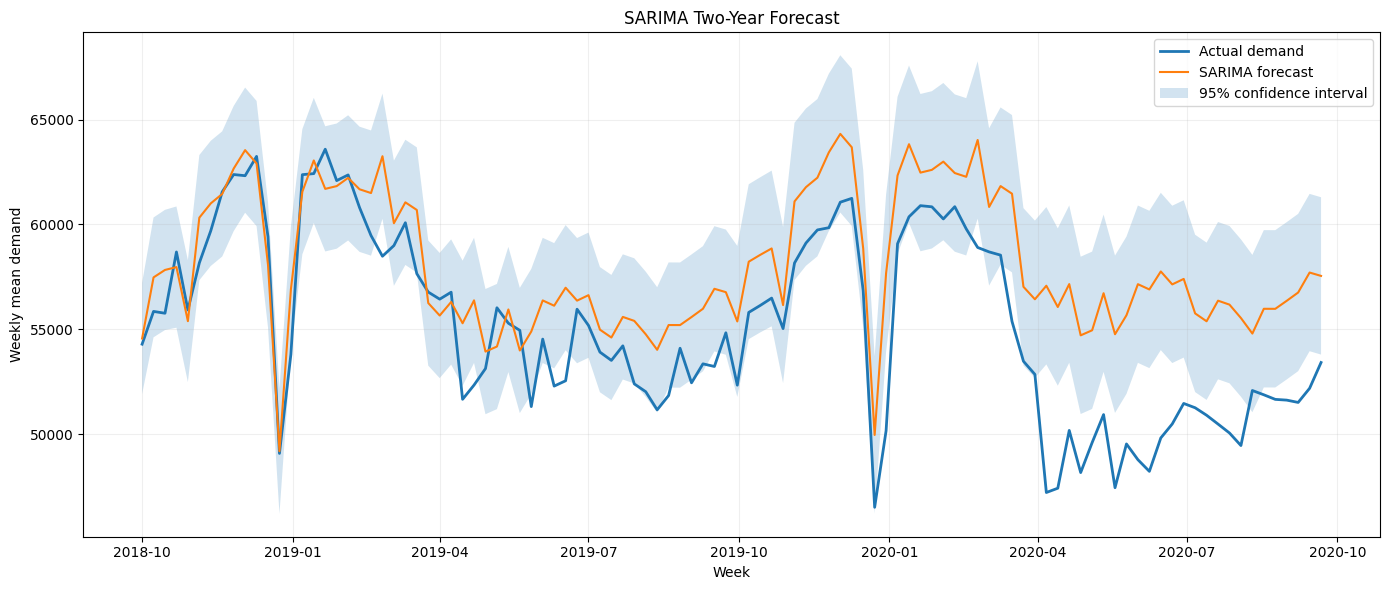

Ljung–Box residual test


,lb_stat,lb_pvalue
12,7.7266,0.8061
26,13.0989,0.9831
52,68.6159,0.0610


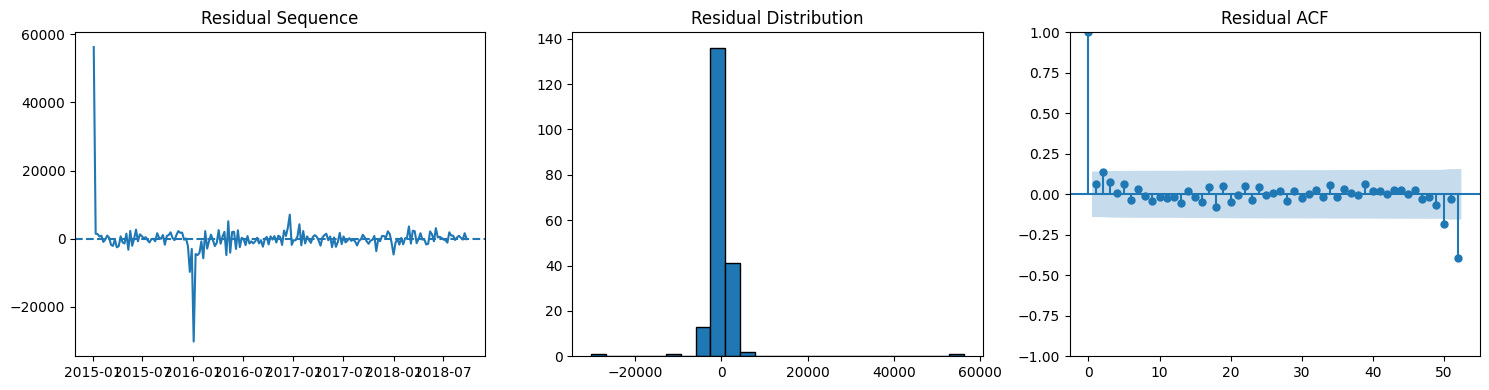

In [6]:
# ------------------------------------------------------------
#  Required SARIMA search and forecast
# ------------------------------------------------------------

# Annual seasonality in weekly data
best_seasonal_order = (0, 1, 1, 52)


def fit_sarima_for_aic(series, order):
    """Fit one SARIMA model and return its AIC."""
    try:
        model = SARIMAX(
            series,
            order=order,
            seasonal_order=best_seasonal_order,
            trend="n",
            enforce_stationarity=False,
            enforce_invertibility=False,
            concentrate_scale=True
        )

        result = model.fit(
            method="lbfgs",
            maxiter=30,
            disp=False,
            cov_type="none"
        )

        return {
            "order": order,
            "AIC": result.aic,
            "converged": result.mle_retvals.get(
                "converged",
                False
            ),
            "status": "Successful"
        }

    except Exception:
        return {
            "order": order,
            "AIC": np.nan,
            "converged": False,
            "status": "Failed"
        }


# Required ranges:
# p = 0–6, d = 0–2 and q = 0–6
sarima_orders = list(
    product(
        range(7),
        range(3),
        range(7)
    )
)

sarima_results = []

print(
    f"Testing {len(sarima_orders)} required "
    "SARIMA combinations..."
)

for number, order in enumerate(
    sarima_orders,
    start=1
):
    sarima_results.append(
        fit_sarima_for_aic(
            train,
            order
        )
    )

    if number % 25 == 0:
        print(
            f"Completed {number}/"
            f"{len(sarima_orders)}"
        )

sarima_search_log = pd.DataFrame(
    sarima_results
)

# Prefer converged models
valid_models = sarima_search_log.loc[
    (sarima_search_log["status"] == "Successful") &
    (sarima_search_log["converged"]) &
    (sarima_search_log["AIC"].notna())
].sort_values("AIC")

# Use all successful models only if none converged
if valid_models.empty:
    valid_models = sarima_search_log.loc[
        (sarima_search_log["status"] == "Successful") &
        (sarima_search_log["AIC"].notna())
    ].sort_values("AIC")

if valid_models.empty:
    raise RuntimeError(
        "No SARIMA combination fitted successfully."
    )

print("\nBest SARIMA combinations")
display(valid_models.head(10).round(3))

print(
    "Successful:",
    (sarima_search_log["status"] == "Successful").sum()
)

print(
    "Failed:",
    (sarima_search_log["status"] == "Failed").sum()
)

# Select the lowest-AIC order
best_order = tuple(
    valid_models.iloc[0]["order"]
)

print("\nSelected order:", best_order)
print(
    "Seasonal order:",
    best_seasonal_order
)

# ------------------------------------------------------------
# Fit the selected SARIMA model
# ------------------------------------------------------------

sarima_model = SARIMAX(
    train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(
    method="lbfgs",
    maxiter=100,
    disp=False
)

# Forecast the common two-year test period
sarima_output = sarima_result.get_forecast(
    steps=len(test)
)

sarima_forecast = pd.Series(
    sarima_output.predicted_mean.to_numpy(),
    index=test.index,
    name="SARIMA"
)

sarima_confidence = sarima_output.conf_int(
    alpha=0.05
)

sarima_lower = pd.Series(
    sarima_confidence.iloc[:, 0].to_numpy(),
    index=test.index
)

sarima_upper = pd.Series(
    sarima_confidence.iloc[:, 1].to_numpy(),
    index=test.index
)

# Keep these names for the remaining cells
forecasts["SARIMA"] = sarima_forecast

intervals["SARIMA"] = (
    sarima_lower,
    sarima_upper
)

# Common evaluation
sarima_metrics = evaluate_forecast(
    "SARIMA",
    test,
    sarima_forecast,
    train
)

display(
    pd.DataFrame(
        [sarima_metrics]
    ).round(4)
)

# ------------------------------------------------------------
# SARIMA forecast with confidence interval
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    test.index,
    test,
    label="Actual demand",
    linewidth=2
)

plt.plot(
    test.index,
    sarima_forecast,
    label="SARIMA forecast"
)

plt.fill_between(
    test.index,
    sarima_lower,
    sarima_upper,
    alpha=0.20,
    label="95% confidence interval"
)

plt.title("SARIMA Two-Year Forecast")
plt.xlabel("Week")
plt.ylabel("Weekly mean demand")
plt.legend()
plt.grid(alpha=0.20)

save_plot("sarima_forecast")

# ------------------------------------------------------------
# Required residual diagnostics
# ------------------------------------------------------------

residuals = pd.Series(
    sarima_result.resid
).dropna()

ljung_box = acorr_ljungbox(
    residuals,
    lags=[12, 26, 52],
    return_df=True
)

print("Ljung–Box residual test")
display(ljung_box.round(4))

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

axes[0].plot(residuals)
axes[0].axhline(0, linestyle="--")
axes[0].set_title("Residual Sequence")

axes[1].hist(
    residuals,
    bins=25,
    edgecolor="black"
)
axes[1].set_title("Residual Distribution")

plot_acf(
    residuals,
    lags=52,
    ax=axes[2]
)
axes[2].set_title("Residual ACF")

plt.tight_layout()

plt.savefig(
    "figures/sarima_residuals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Save all successful and failed combinations
sarima_search_log.to_csv(
    "results/sarima_search_log.csv",
    index=False
)

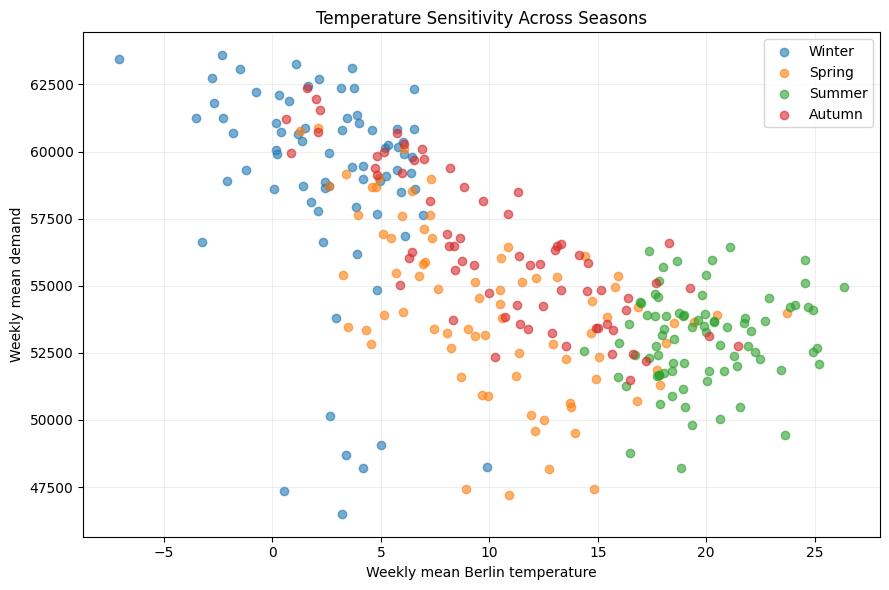

,Model,MAE,RMSE,sMAPE (%),MASE,RMSSE,Median AE,90th percentile AE,Bias,Error stability
2,SARIMAX Full,2977.1783,3776.7850,5.4214,2.2036,2.0554,2277.4049,6732.5496,2900.9749,2323.9008
0,SARIMA,3109.6698,3836.6129,5.6407,2.3016,2.0879,2725.4857,6133.7022,2903.5610,2247.1208
1,SARIMAX Temperature,3871.1626,4696.3847,6.9479,2.8653,2.5558,3573.7357,7699.5045,3822.9849,2658.9716


Observed test temperatures are used, so SARIMAX forecasts are conditional.


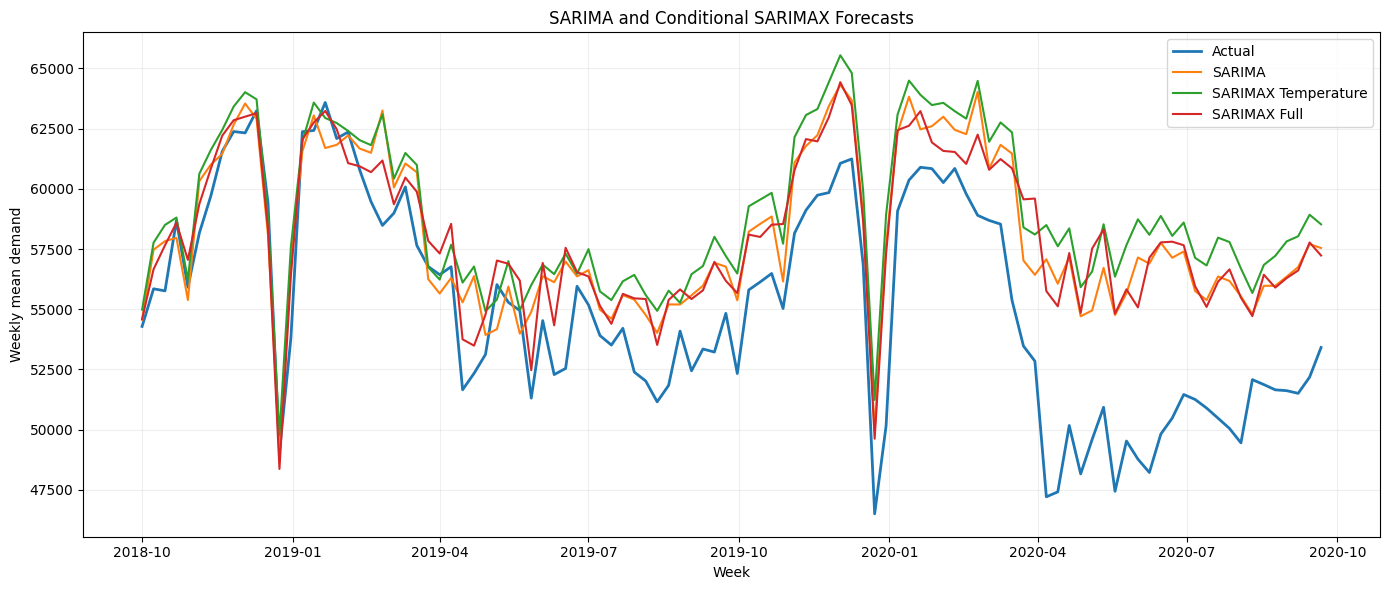

In [7]:
# ------------------------------------------------------------
# Download Berlin daily temperature
# ------------------------------------------------------------

weather_parameters = {
    "latitude": 52.52,
    "longitude": 13.41,
    "start_date": hourly.index.min().date().isoformat(),
    "end_date": hourly.index.max().date().isoformat(),
    "daily": (
        "temperature_2m_mean,"
        "temperature_2m_min,"
        "temperature_2m_max"
    ),
    "timezone": "UTC"
}

weather_response = requests.get(
    "https://archive-api.open-meteo.com/v1/archive",
    params=weather_parameters,
    timeout=120
)

weather_response.raise_for_status()
weather_json = weather_response.json()

weather = pd.DataFrame({
    "date": pd.to_datetime(
        weather_json["daily"]["time"]
    ),
    "temp_mean": weather_json["daily"][
        "temperature_2m_mean"
    ],
    "temp_min": weather_json["daily"][
        "temperature_2m_min"
    ],
    "temp_max": weather_json["daily"][
        "temperature_2m_max"
    ]
}).set_index("date")

# Calendar variables
german_holidays = holidays.Germany(
    years=range(2015, 2021)
)

weather["holiday"] = [
    int(date.date() in german_holidays)
    for date in weather.index
]

weather["working_day"] = (
    (weather.index.weekday < 5) &
    (weather["holiday"] == 0)
).astype(int)

weather["christmas_newyear"] = (
    (
        (weather.index.month == 12) &
        (weather.index.day >= 20)
    ) |
    (
        (weather.index.month == 1) &
        (weather.index.day <= 7)
    )
).astype(int)

weather["hdd"] = np.maximum(
    18 - weather["temp_mean"],
    0
)

weather["cdd"] = np.maximum(
    weather["temp_mean"] - 22,
    0
)

# Weekly weather variables
weekly_weather = weather.resample(
    CONFIG["week_frequency"],
    label="left",
    closed="left"
).agg({
    "temp_mean": "mean",
    "temp_min": "min",
    "temp_max": "max",
    "holiday": "sum",
    "working_day": "sum",
    "christmas_newyear": "max",
    "hdd": "sum",
    "cdd": "sum"
})

week_number = (
    weekly_weather.index
    .isocalendar()
    .week
    .astype(int)
)

weekly_weather["week_sin"] = np.sin(
    2 * np.pi * week_number / 52
)

weekly_weather["week_cos"] = np.cos(
    2 * np.pi * week_number / 52
)

weekly_weather = (
    weekly_weather
    .reindex(weekly.index)
    .interpolate()
    .ffill()
    .bfill()
)

weekly_dataset = pd.concat(
    [
        weekly.rename("demand"),
        weekly_weather
    ],
    axis=1
)

# Temperature relationship by season
season_name = np.select(
    [
        weekly_dataset.index.month.isin([12, 1, 2]),
        weekly_dataset.index.month.isin([3, 4, 5]),
        weekly_dataset.index.month.isin([6, 7, 8])
    ],
    [
        "Winter",
        "Spring",
        "Summer"
    ],
    default="Autumn"
)

plt.figure(figsize=(9, 6))

for season in [
    "Winter",
    "Spring",
    "Summer",
    "Autumn"
]:
    mask = season_name == season

    plt.scatter(
        weekly_dataset.loc[mask, "temp_mean"],
        weekly_dataset.loc[mask, "demand"],
        label=season,
        alpha=0.60
    )

plt.title("Temperature Sensitivity Across Seasons")
plt.xlabel("Weekly mean Berlin temperature")
plt.ylabel("Weekly mean demand")
plt.legend()
plt.grid(alpha=0.20)
save_plot("seasonal_temperature_relationship")

# ------------------------------------------------------------
# SARIMAX fitting function
# ------------------------------------------------------------

def fit_sarimax(name, feature_columns):
    train_exog = weekly_dataset.loc[
        train.index,
        feature_columns
    ]

    test_exog = weekly_dataset.loc[
        test.index,
        feature_columns
    ]

    scaler = StandardScaler()

    train_scaled = scaler.fit_transform(
        train_exog
    )

    test_scaled = scaler.transform(
        test_exog
    )

    model = SARIMAX(
        train,
        exog=train_scaled,
        order=best_order,
        seasonal_order=best_seasonal_order,
        trend="n",
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted = model.fit(
        disp=False,
        maxiter=200
    )

    output = fitted.get_forecast(
        steps=len(test),
        exog=test_scaled
    )

    forecast = pd.Series(
        output.predicted_mean.to_numpy(),
        index=test.index
    )

    confidence = output.conf_int(
        alpha=0.05
    )

    lower = pd.Series(
        confidence.iloc[:, 0].to_numpy(),
        index=test.index
    )

    upper = pd.Series(
        confidence.iloc[:, 1].to_numpy(),
        index=test.index
    )

    return fitted, forecast, lower, upper


temperature_features = [
    "temp_mean"
]

full_features = [
    "temp_mean",
    "hdd",
    "cdd",
    "holiday",
    "working_day",
    "christmas_newyear",
    "week_sin",
    "week_cos"
]

sarimax_temp_result, sarimax_temp_forecast, temp_lower, temp_upper = (
    fit_sarimax(
        "SARIMAX Temperature",
        temperature_features
    )
)

sarimax_full_result, sarimax_full_forecast, full_lower, full_upper = (
    fit_sarimax(
        "SARIMAX Full",
        full_features
    )
)

forecasts[
    "SARIMAX Temperature"
] = sarimax_temp_forecast

forecasts[
    "SARIMAX Full"
] = sarimax_full_forecast

intervals[
    "SARIMAX Temperature"
] = (
    temp_lower,
    temp_upper
)

intervals[
    "SARIMAX Full"
] = (
    full_lower,
    full_upper
)

sarimax_results = pd.DataFrame([
    evaluate_forecast(
        "SARIMA",
        test,
        sarima_forecast,
        train
    ),
    evaluate_forecast(
        "SARIMAX Temperature",
        test,
        sarimax_temp_forecast,
        train
    ),
    evaluate_forecast(
        "SARIMAX Full",
        test,
        sarimax_full_forecast,
        train
    )
])

display(
    sarimax_results
    .sort_values("RMSE")
    .round(4)
)

print(
    "Observed test temperatures are used, "
    "so SARIMAX forecasts are conditional."
)

plt.figure(figsize=(14, 6))
plt.plot(test.index, test, label="Actual", linewidth=2)
plt.plot(test.index, sarima_forecast, label="SARIMA")
plt.plot(
    test.index,
    sarimax_temp_forecast,
    label="SARIMAX Temperature"
)
plt.plot(
    test.index,
    sarimax_full_forecast,
    label="SARIMAX Full"
)

plt.title("SARIMA and Conditional SARIMAX Forecasts")
plt.xlabel("Week")
plt.ylabel("Weekly mean demand")
plt.legend()
plt.grid(alpha=0.20)
save_plot("sarima_sarimax_comparison")

Lag and rolling-feature checks passed.
Best parameters:
{'model__min_samples_leaf': 15, 'model__max_leaf_nodes': 15, 'model__max_iter': 250, 'model__max_depth': 4, 'model__learning_rate': 0.05, 'model__l2_regularization': 1.0}


,Model,MAE,RMSE,sMAPE (%),MASE,RMSSE,Median AE,90th percentile AE,Bias,Error stability
0,HistGradientBoosting,2382.8207,3115.9765,4.396,1.7637,1.6957,1595.1215,5424.8726,1867.6318,2007.8533


The feature model uses recursive demand lags. Actual test demand was not used.


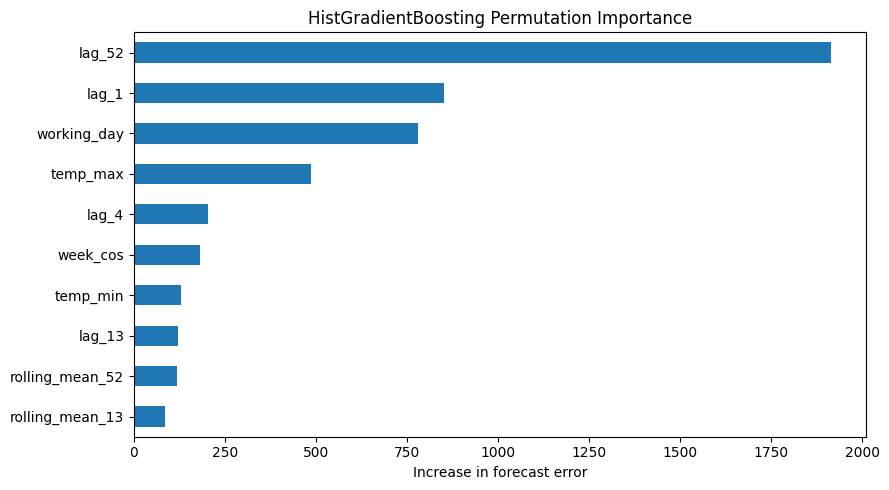

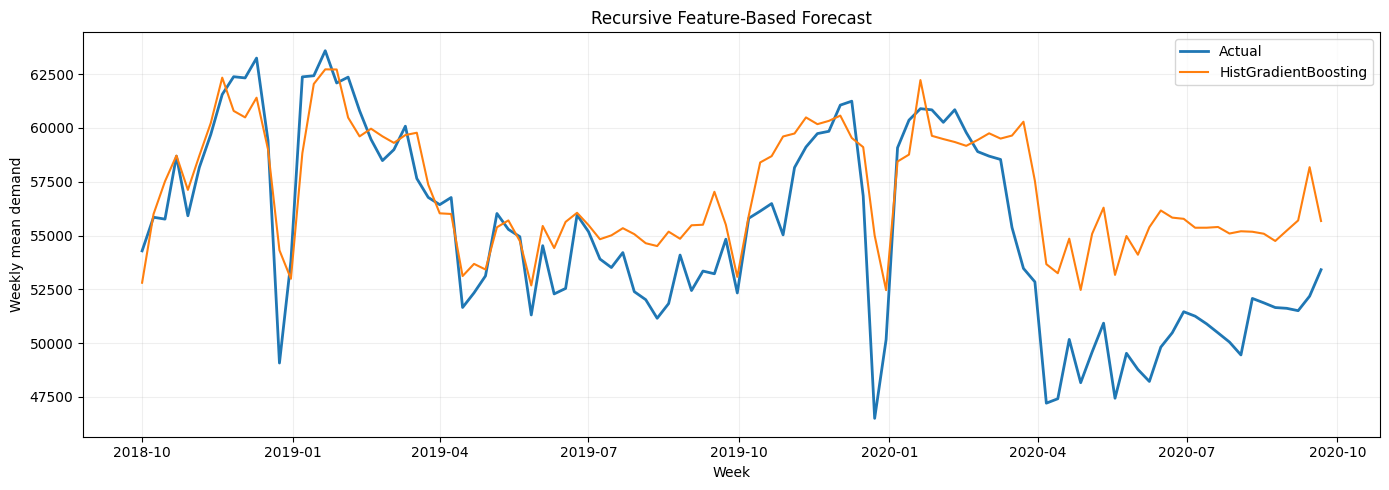

['models/hist_gradient_boosting.joblib']

In [8]:
# ------------------------------------------------------------
# Create one leakage-safe feature row
# ------------------------------------------------------------

def make_feature_row(history, exogenous_row):
    history = pd.Series(history, dtype=float)

    return {
        "lag_1": history.iloc[-1],
        "lag_2": history.iloc[-2],
        "lag_4": history.iloc[-4],
        "lag_13": history.iloc[-13],
        "lag_52": history.iloc[-52],
        "rolling_mean_4": history.iloc[-4:].mean(),
        "rolling_mean_13": history.iloc[-13:].mean(),
        "rolling_mean_52": history.iloc[-52:].mean(),
        "rolling_std_13": history.iloc[-13:].std(),
        "temp_mean": exogenous_row["temp_mean"],
        "temp_min": exogenous_row["temp_min"],
        "temp_max": exogenous_row["temp_max"],
        "hdd": exogenous_row["hdd"],
        "cdd": exogenous_row["cdd"],
        "holiday": exogenous_row["holiday"],
        "working_day": exogenous_row["working_day"],
        "christmas_newyear":
            exogenous_row["christmas_newyear"],
        "week_sin": exogenous_row["week_sin"],
        "week_cos": exogenous_row["week_cos"]
    }


# Training rows use only previous demand observations
training_rows = []
training_targets = []

training_dataset = weekly_dataset.loc[
    train.index
]

for position in range(
    52,
    len(training_dataset)
):
    date = training_dataset.index[position]

    historical_demand = training_dataset[
        "demand"
    ].iloc[:position]

    row = make_feature_row(
        historical_demand,
        training_dataset.loc[date]
    )

    training_rows.append(row)
    training_targets.append(
        training_dataset.loc[date, "demand"]
    )

X_hgb = pd.DataFrame(
    training_rows
)

y_hgb = pd.Series(
    training_targets
)

# Basic leakage checks
assert np.isclose(
    X_hgb.iloc[0]["lag_1"],
    training_dataset["demand"].iloc[51]
)

assert np.isclose(
    X_hgb.iloc[0]["rolling_mean_4"],
    training_dataset["demand"].iloc[48:52].mean()
)

print("Lag and rolling-feature checks passed.")

# Reproducible pipeline and time-series tuning
hgb_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "model",
        HistGradientBoostingRegressor(
            random_state=CONFIG["seed"]
        )
    )
])

parameter_space = {
    "model__learning_rate": [
        0.03,
        0.05,
        0.08,
        0.10
    ],
    "model__max_iter": [
        150,
        250,
        400
    ],
    "model__max_leaf_nodes": [
        15,
        31,
        63
    ],
    "model__max_depth": [
        None,
        4,
        6
    ],
    "model__min_samples_leaf": [
        5,
        10,
        15
    ],
    "model__l2_regularization": [
        0,
        0.1,
        1.0
    ]
}

time_split = TimeSeriesSplit(
    n_splits=4
)

hgb_search = RandomizedSearchCV(
    estimator=hgb_pipeline,
    param_distributions=parameter_space,
    n_iter=15,
    scoring="neg_root_mean_squared_error",
    cv=time_split,
    random_state=CONFIG["seed"],
    n_jobs=-1
)

hgb_search.fit(
    X_hgb,
    y_hgb
)

print("Best parameters:")
print(hgb_search.best_params_)

# Recursive fixed-origin forecast
recursive_history = list(
    train.to_numpy()
)

hgb_predictions = []

for date in test.index:
    feature_row = make_feature_row(
        recursive_history,
        weekly_dataset.loc[date]
    )

    prediction = hgb_search.predict(
        pd.DataFrame([feature_row])
    )[0]

    hgb_predictions.append(prediction)
    recursive_history.append(prediction)

hgb_forecast = pd.Series(
    hgb_predictions,
    index=test.index
)

forecasts[
    "HistGradientBoosting"
] = hgb_forecast

display(
    pd.DataFrame([
        evaluate_forecast(
            "HistGradientBoosting",
            test,
            hgb_forecast,
            train
        )
    ]).round(4)
)

print(
    "The feature model uses recursive demand lags. "
    "Actual test demand was not used."
)

# Permutation importance on recent training observations
importance_result = permutation_importance(
    hgb_search.best_estimator_,
    X_hgb.tail(52),
    y_hgb.tail(52),
    n_repeats=10,
    random_state=CONFIG["seed"],
    scoring="neg_root_mean_squared_error"
)

importance = pd.Series(
    importance_result.importances_mean,
    index=X_hgb.columns
).sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(9, 5))
importance.sort_values().plot(kind="barh")
plt.title("HistGradientBoosting Permutation Importance")
plt.xlabel("Increase in forecast error")
plt.ylabel("")
save_plot("hgb_permutation_importance")

plt.figure(figsize=(14, 5))
plt.plot(test.index, test, label="Actual", linewidth=2)
plt.plot(
    test.index,
    hgb_forecast,
    label="HistGradientBoosting"
)

plt.title("Recursive Feature-Based Forecast")
plt.xlabel("Week")
plt.ylabel("Weekly mean demand")
plt.legend()
plt.grid(alpha=0.20)
save_plot("hgb_forecast")

joblib.dump(
    hgb_search.best_estimator_,
    "models/hist_gradient_boosting.joblib"
)

Training samples: (1084, 168, 1)
Validation samples: (272, 168, 1)
Epoch 1/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.9805 - val_loss: 0.9141
Epoch 2/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.8936 - val_loss: 0.7767
Epoch 3/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.6814 - val_loss: 0.5484
Epoch 4/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.5378 - val_loss: 0.4713
Epoch 5/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.4839 - val_loss: 0.4473
Epoch 6/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4610 - val_loss: 0.4329
Epoch 7/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4463 - val_loss: 0.4210
Epoch 8/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4356 - val_loss: 0.4118
Epoch 9/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4262 - val_loss: 0.4031
Epoch 10/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4167 - val_loss: 0.3937
Epoch 11/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4068 - val_loss: 0.3

,Architecture,Validation loss,Best epoch
1,LSTM-64,0.201559,15
0,LSTM-32,0.343509,15


Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.9472
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6354
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4966
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4528
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.4305
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4078
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3880
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3634
Epoch 9/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3226
Epoch 10/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2790
Epoch 11/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2691
Epoch 12/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2478
Epoch 13/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2265
Epoch 14/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2154
Epoch 15/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2010


,Model,MAE,RMSE,sMAPE (%),MASE,RMSSE,Median AE,90th percentile AE,Bias,Error stability
0,LSTM,5941.0517,7195.7981,10.5078,4.3973,3.916,5955.3292,11285.0906,5558.2788,4059.9772


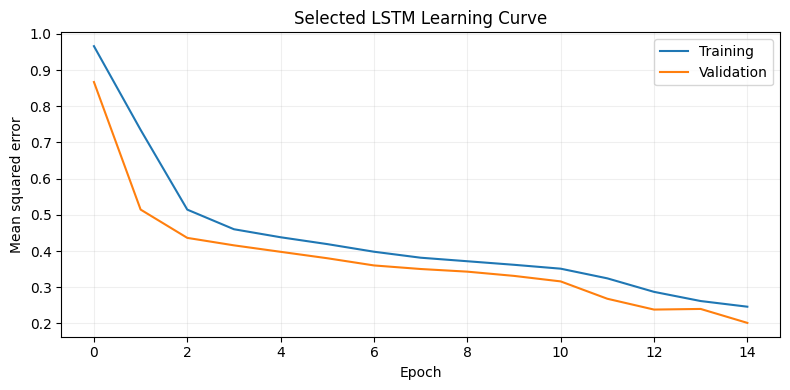

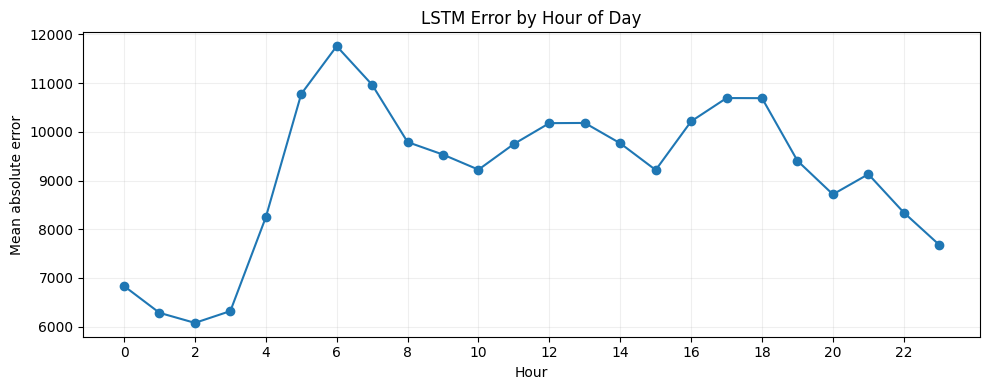

In [9]:
# ------------------------------------------------------------
# Hourly train and test periods
# ------------------------------------------------------------

hourly_test_start = test.index.min()

hourly_test_index = pd.date_range(
    start=hourly_test_start,
    periods=len(test) * 168,
    freq="h"
)

hourly_train = hourly.loc[
    hourly.index < hourly_test_start
]

hourly_test = hourly.reindex(
    hourly_test_index
)

assert hourly_test.notna().all()

# Fit scaler only on training observations
lstm_scaler = StandardScaler()

hourly_train_scaled = lstm_scaler.fit_transform(
    hourly_train.to_numpy().reshape(-1, 1)
).ravel()

INPUT_HOURS = 168
OUTPUT_HOURS = 168


def create_lstm_samples(
    values,
    input_hours=168,
    output_hours=168,
    step=24
):
    """Create past-week to next-week sequences."""
    X, y = [], []

    final_start = (
        len(values) -
        input_hours -
        output_hours
    )

    for start in range(
        0,
        final_start + 1,
        step
    ):
        middle = start + input_hours
        end = middle + output_hours

        X.append(
            values[start:middle]
        )

        y.append(
            values[middle:end]
        )

    return (
        np.asarray(X)[..., np.newaxis],
        np.asarray(y)
    )


X_lstm, y_lstm = create_lstm_samples(
    hourly_train_scaled
)

validation_start = int(
    len(X_lstm) * 0.80
)

X_lstm_train = X_lstm[:validation_start]
y_lstm_train = y_lstm[:validation_start]

X_lstm_validation = X_lstm[validation_start:]
y_lstm_validation = y_lstm[validation_start:]

print("Training samples:",
      X_lstm_train.shape)

print("Validation samples:",
      X_lstm_validation.shape)


def build_lstm(units, dropout):
    """Build a compact weekly-output LSTM."""
    model = Sequential([
        LSTM(
            units,
            input_shape=(INPUT_HOURS, 1)
        ),
        Dropout(dropout),
        Dense(OUTPUT_HOURS)
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=0.001
        ),
        loss="mse"
    )

    return model


architectures = [
    {
        "name": "LSTM-32",
        "units": 32,
        "dropout": 0.10
    },
    {
        "name": "LSTM-64",
        "units": 64,
        "dropout": 0.20
    }
]

architecture_results = []
best_validation_loss = np.inf
best_architecture = None
best_epochs = None
best_history = None

for architecture in architectures:
    tf.keras.backend.clear_session()

    model = build_lstm(
        architecture["units"],
        architecture["dropout"]
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        X_lstm_train,
        y_lstm_train,
        validation_data=(
            X_lstm_validation,
            y_lstm_validation
        ),
        epochs=15,
        batch_size=64,
        shuffle=False,
        callbacks=[early_stopping],
        verbose=1
    )

    minimum_loss = min(
        history.history["val_loss"]
    )

    selected_epoch = (
        np.argmin(
            history.history["val_loss"]
        ) + 1
    )

    architecture_results.append({
        "Architecture": architecture["name"],
        "Validation loss": minimum_loss,
        "Best epoch": selected_epoch
    })

    if minimum_loss < best_validation_loss:
        best_validation_loss = minimum_loss
        best_architecture = architecture
        best_epochs = selected_epoch
        best_history = history.history

architecture_table = pd.DataFrame(
    architecture_results
).sort_values(
    "Validation loss"
)

display(architecture_table.round(6))

# Refit selected architecture on all training samples
tf.keras.backend.clear_session()

lstm_model = build_lstm(
    best_architecture["units"],
    best_architecture["dropout"]
)

lstm_model.fit(
    X_lstm,
    y_lstm,
    epochs=best_epochs,
    batch_size=64,
    shuffle=False,
    verbose=1
)

# Recursive 104-week hourly forecast
current_sequence = hourly_train_scaled[
    -INPUT_HOURS:
].copy()

predicted_blocks = []

for _ in range(len(test)):
    next_block = lstm_model.predict(
        current_sequence.reshape(
            1,
            INPUT_HOURS,
            1
        ),
        verbose=0
    )[0]

    predicted_blocks.extend(next_block)
    current_sequence = next_block.copy()

hourly_lstm_forecast = lstm_scaler.inverse_transform(
    np.asarray(
        predicted_blocks
    ).reshape(-1, 1)
).ravel()

hourly_lstm_series = pd.Series(
    hourly_lstm_forecast,
    index=hourly_test_index
)

lstm_weekly_forecast = hourly_lstm_series.resample(
    CONFIG["week_frequency"],
    label="left",
    closed="left"
).mean().reindex(test.index)

forecasts["LSTM"] = lstm_weekly_forecast

display(
    pd.DataFrame([
        evaluate_forecast(
            "LSTM",
            test,
            lstm_weekly_forecast,
            train
        )
    ]).round(4)
)

# Training curve
plt.figure(figsize=(8, 4))
plt.plot(
    best_history["loss"],
    label="Training"
)

plt.plot(
    best_history["val_loss"],
    label="Validation"
)

plt.title("Selected LSTM Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("Mean squared error")
plt.legend()
plt.grid(alpha=0.20)
save_plot("lstm_learning_curve")

# Hour-of-day error profile
hourly_errors = pd.Series(
    np.abs(
        hourly_test.to_numpy() -
        hourly_lstm_forecast
    ),
    index=hourly_test_index
)

hourly_error_profile = hourly_errors.groupby(
    hourly_errors.index.hour
).mean()

plt.figure(figsize=(10, 4))
plt.plot(
    hourly_error_profile.index,
    hourly_error_profile.values,
    marker="o"
)

plt.title("LSTM Error by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Mean absolute error")
plt.xticks(range(0, 24, 2))
plt.grid(alpha=0.20)
save_plot("lstm_hourly_error_profile")

lstm_model.save(
    "models/hourly_lstm.keras"
)

All models predict exactly the same dates.


,Model,MAE,RMSE,sMAPE (%),MASE,RMSSE,Median AE,90th percentile AE,Bias,Error stability,Skill vs Seasonal Naive
0,Seasonal Naive,2288.4892,2988.2483,4.2067,1.6938,1.6262,1703.6875,4894.1970,1747.8046,1921.5736,0.0000
1,HistGradientBoosting,2382.8207,3115.9765,4.3960,1.7637,1.6957,1595.1215,5424.8726,1867.6318,2007.8533,-0.0427
2,SARIMAX Full,2977.1783,3776.7850,5.4214,2.2036,2.0554,2277.4049,6732.5496,2900.9749,2323.9008,-0.2639
3,SARIMA,3109.6698,3836.6129,5.6407,2.3016,2.0879,2725.4857,6133.7022,2903.5610,2247.1208,-0.2839
4,Mean,3789.8453,4402.0588,6.8738,2.8051,2.3956,3737.3382,6676.3686,561.1923,2239.4629,-0.4731
5,Drift,3850.7758,4466.4944,6.9823,2.8502,2.4307,3776.0060,6617.6209,966.3860,2262.9844,-0.4947
6,Naive,3858.1478,4475.7671,6.9954,2.8556,2.4358,3790.3512,6650.1137,984.5335,2268.7412,-0.4978
7,SARIMAX Temperature,3871.1626,4696.3847,6.9479,2.8653,2.5558,3573.7357,7699.5045,3822.9849,2658.9716,-0.5716
8,LSTM,5941.0517,7195.7981,10.5078,4.3973,3.9160,5955.3292,11285.0906,5558.2788,4059.9772,-1.4080


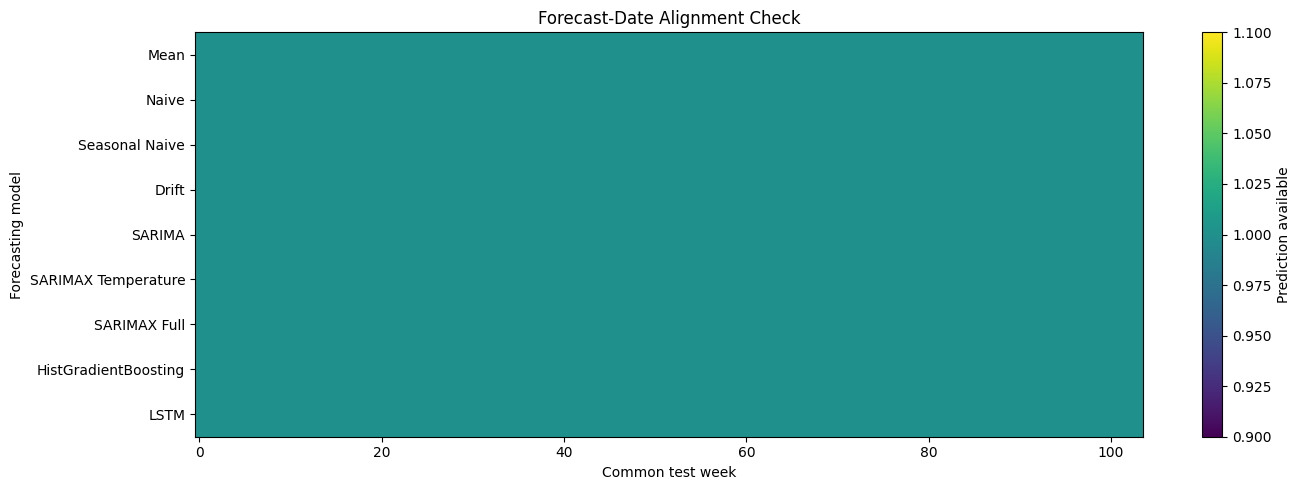

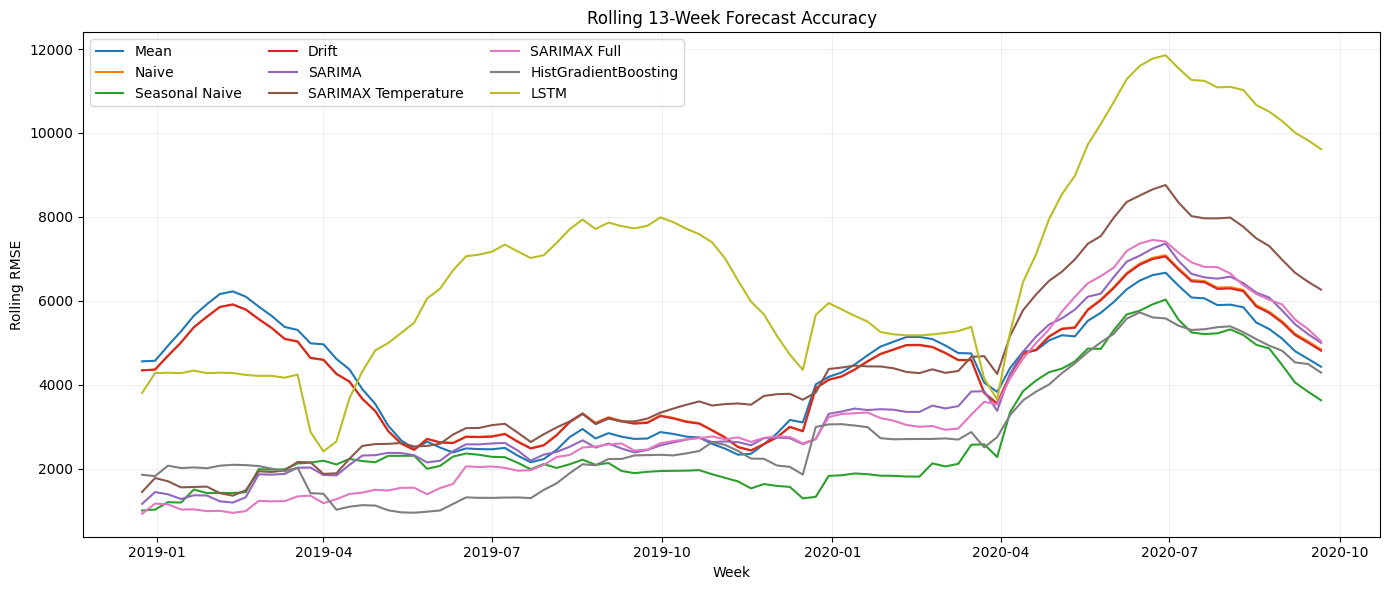

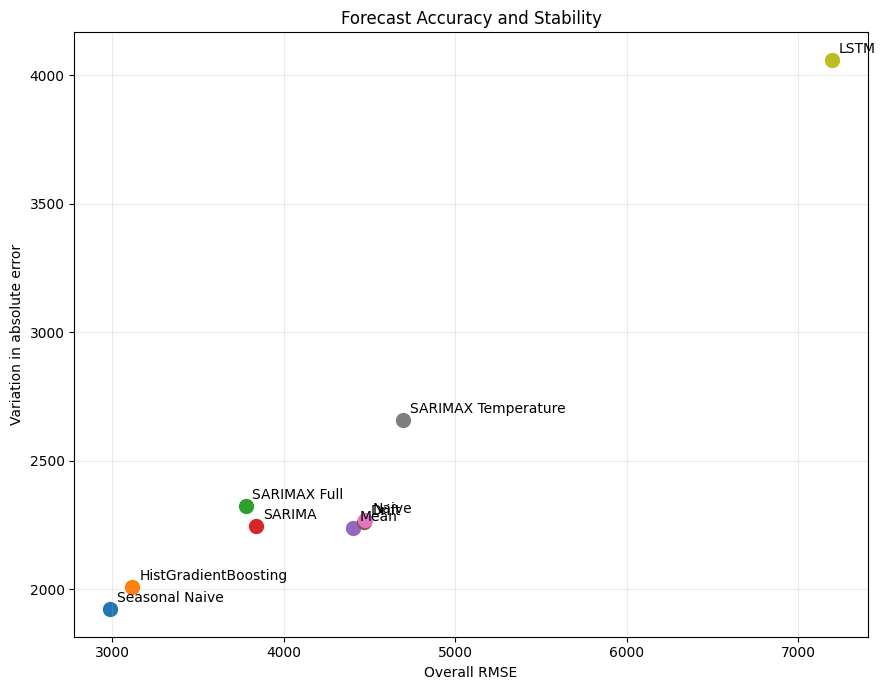

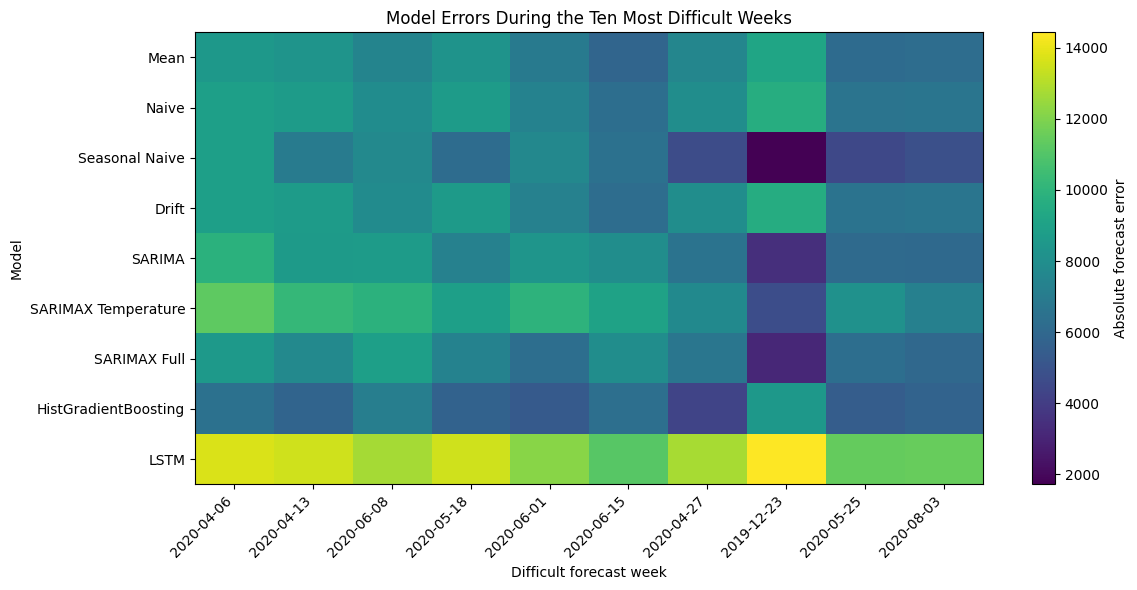

,Model,Coverage (%),Mean width,Interval score
0,SARIMA,62.5000,6717.4737,35405.0521
1,SARIMAX Temperature,67.3077,9052.3869,30789.9810
2,SARIMAX Full,54.8077,5228.9562,45977.3288


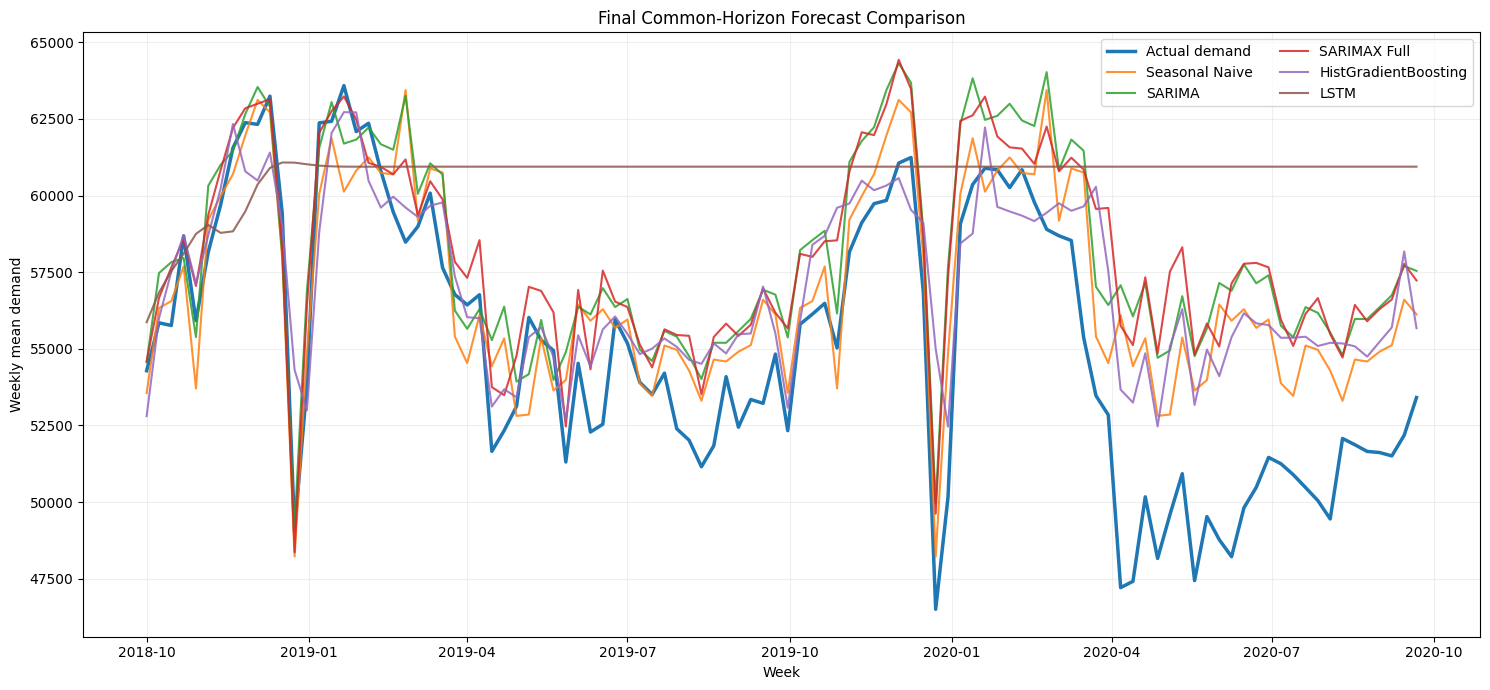

Best RMSE model: Seasonal Naive
All figures, tables and models were saved.


In [10]:
# ------------------------------------------------------------
# Confirm experimental fairness
# ------------------------------------------------------------

check_forecast_dates(
    test,
    forecasts
)

# Common metrics table
final_metrics = pd.DataFrame([
    evaluate_forecast(
        name,
        test,
        forecast,
        train
    )
    for name, forecast in forecasts.items()
])

seasonal_rmse = final_metrics.loc[
    final_metrics["Model"] ==
    "Seasonal Naive",
    "RMSE"
].iloc[0]

final_metrics[
    "Skill vs Seasonal Naive"
] = (
    1 -
    final_metrics["RMSE"] /
    seasonal_rmse
)

final_metrics = final_metrics.sort_values(
    "RMSE"
).reset_index(drop=True)

display(final_metrics.round(4))

# ------------------------------------------------------------
# Plot 1: Forecast-date alignment matrix
# ------------------------------------------------------------

alignment_matrix = np.array([
    forecast.reindex(test.index).notna().astype(int)
    for forecast in forecasts.values()
])

plt.figure(figsize=(14, 5))
plt.imshow(
    alignment_matrix,
    aspect="auto",
    interpolation="nearest"
)

plt.yticks(
    range(len(forecasts)),
    list(forecasts.keys())
)

plt.xlabel("Common test week")
plt.ylabel("Forecasting model")
plt.title("Forecast-Date Alignment Check")
plt.colorbar(label="Prediction available")
save_plot("forecast_date_alignment")

# ------------------------------------------------------------
# Plot 2: Rolling 13-week RMSE
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

for name, forecast in forecasts.items():
    squared_error = (
        test - forecast
    ) ** 2

    rolling_rmse = np.sqrt(
        squared_error
        .rolling(13)
        .mean()
    )

    plt.plot(
        rolling_rmse.index,
        rolling_rmse,
        label=name
    )

plt.title("Rolling 13-Week Forecast Accuracy")
plt.xlabel("Week")
plt.ylabel("Rolling RMSE")
plt.legend(ncol=3)
plt.grid(alpha=0.20)
save_plot("rolling_rmse")

# ------------------------------------------------------------
# Plot 3: Accuracy-stability comparison
# ------------------------------------------------------------

plt.figure(figsize=(9, 7))

for _, row in final_metrics.iterrows():
    plt.scatter(
        row["RMSE"],
        row["Error stability"],
        s=100
    )

    plt.annotate(
        row["Model"],
        (
            row["RMSE"],
            row["Error stability"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Overall RMSE")
plt.ylabel("Variation in absolute error")
plt.title("Forecast Accuracy and Stability")
plt.grid(alpha=0.25)
save_plot("accuracy_stability")

# ------------------------------------------------------------
# Plot 4: Worst-week error fingerprint
# ------------------------------------------------------------

absolute_error_table = pd.DataFrame({
    name: np.abs(test - forecast)
    for name, forecast in forecasts.items()
})

absolute_error_table[
    "Average model error"
] = absolute_error_table.mean(axis=1)

worst_dates = absolute_error_table[
    "Average model error"
].nlargest(10).index

worst_week_errors = absolute_error_table.loc[
    worst_dates,
    list(forecasts.keys())
]

plt.figure(figsize=(12, 6))

image = plt.imshow(
    worst_week_errors.T,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(
    image,
    label="Absolute forecast error"
)

plt.yticks(
    range(len(worst_week_errors.columns)),
    worst_week_errors.columns
)

plt.xticks(
    range(len(worst_dates)),
    [
        date.strftime("%Y-%m-%d")
        for date in worst_dates
    ],
    rotation=45,
    ha="right"
)

plt.title("Model Errors During the Ten Most Difficult Weeks")
plt.xlabel("Difficult forecast week")
plt.ylabel("Model")
save_plot("worst_week_error_fingerprint")

# ------------------------------------------------------------
# Prediction-interval quality
# ------------------------------------------------------------

def interval_score(
    actual,
    lower,
    upper,
    alpha=0.05
):
    actual = np.asarray(actual)
    lower = np.asarray(lower)
    upper = np.asarray(upper)

    score = upper - lower

    score += (
        2 / alpha *
        (lower - actual) *
        (actual < lower)
    )

    score += (
        2 / alpha *
        (actual - upper) *
        (actual > upper)
    )

    return score.mean()


interval_rows = []

for name, (lower, upper) in intervals.items():
    inside = (
        (test >= lower) &
        (test <= upper)
    )

    interval_rows.append({
        "Model": name,
        "Coverage (%)": inside.mean() * 100,
        "Mean width": (
            upper - lower
        ).mean(),
        "Interval score": interval_score(
            test,
            lower,
            upper
        )
    })

interval_table = pd.DataFrame(
    interval_rows
)

display(interval_table.round(4))

# ------------------------------------------------------------
# Final forecast plot
# ------------------------------------------------------------

final_plot_models = [
    "Seasonal Naive",
    "SARIMA",
    "SARIMAX Full",
    "HistGradientBoosting",
    "LSTM"
]

plt.figure(figsize=(15, 7))
plt.plot(
    test.index,
    test,
    label="Actual demand",
    linewidth=2.5
)

for name in final_plot_models:
    plt.plot(
        test.index,
        forecasts[name],
        label=name,
        alpha=0.85
    )

plt.title("Final Common-Horizon Forecast Comparison")
plt.xlabel("Week")
plt.ylabel("Weekly mean demand")
plt.legend(ncol=2)
plt.grid(alpha=0.20)
save_plot("final_forecast_comparison")

# ------------------------------------------------------------
# Save reproducible outputs
# ------------------------------------------------------------

forecast_table = pd.DataFrame({
    "Actual": test
})

for name, forecast in forecasts.items():
    forecast_table[name] = forecast

forecast_table.to_csv(
    "results/all_forecasts.csv"
)

final_metrics.to_csv(
    "results/model_metrics.csv",
    index=False
)

interval_table.to_csv(
    "results/interval_metrics.csv",
    index=False
)

stationarity_table.to_csv(
    "results/stationarity_tests.csv",
    index=False
)

run_manifest = {
    "data_start": str(hourly.index.min()),
    "data_end": str(hourly.index.max()),
    "training_start": str(train.index.min()),
    "training_end": str(train.index.max()),
    "test_start": str(test.index.min()),
    "test_end": str(test.index.max()),
    "test_weeks": len(test),
    "seasonal_period": CONFIG["seasonal_period"],
    "random_seed": CONFIG["seed"],
    "feature_model":
        "HistGradientBoostingRegressor",
    "lstm_forecast":
        "Recursive 168-hour blocks"
}

with open(
    "results/run_manifest.json",
    "w",
    encoding="utf-8"
) as manifest_file:
    json.dump(
        run_manifest,
        manifest_file,
        indent=4
    )

print("Best RMSE model:",
      final_metrics.iloc[0]["Model"])

print("All figures, tables and models were saved.")